In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import joblib
import json
import re
from functools import partial

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import IsolationForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,accuracy_score, precision_score, recall_score, f1_score,classification_report
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder


from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense,BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import EarlyStopping

from scikeras.wrappers import KerasRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import optuna
import tensorflow as tf
import seaborn as sns
import time







In [9]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")
FOLDER_TMP      = os.getenv("FOLDER_TMP")

SEED            = int(os.getenv("SEED"))

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

[OK] Conexión establecida con TimescaleDB.


In [10]:
SQL='select * from vectores'
df = pd.read_sql(SQL, engine)


In [11]:
lista_label = df['label'].unique().tolist()

In [12]:
len(lista_label)

54

In [13]:
df_result=df[ ['vector_id','execution_name','label'] ].copy()


In [14]:
df_result

,vector_id,execution_name,label
0,190754,light-oauth2-data-1719592986.tar,correct
1,190755,light-oauth2-data-1719592986.tar,correct
2,190756,light-oauth2-data-1719592986.tar,correct
3,190757,light-oauth2-data-1719592986.tar,correct
4,190843,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400
...,...,...,...
90185,280939,light-oauth2-data-1725866154.tar,delete_user_404_no_user
90186,280940,light-oauth2-data-1725866154.tar,update_password_401_wrong_password
90187,280941,light-oauth2-data-1725866154.tar,update_password_404_user_not_found
90188,280942,light-oauth2-data-1725866154.tar,update_password_400_not_match


In [15]:
filename = f'{FOLDER_SALIDA}/lista_metric_name_vector.json'

with open(filename, "r", encoding="utf-8") as f:
    lista_metric_name_vector = json.load(f)

# <span style="color:#2ca02c">1. Recuperamos separación ya hecha en conjuntos de train, val y test</span>

In [16]:
SQL='select * from vectores_split'
df_split = pd.read_sql(SQL, engine)

In [17]:
df_result = pd.merge(df_result, df_split, on="vector_id", how="inner")

In [18]:
df_result

,vector_id,execution_name,label,split_type
0,190754,light-oauth2-data-1719592986.tar,correct,test
1,190755,light-oauth2-data-1719592986.tar,correct,train
2,190756,light-oauth2-data-1719592986.tar,correct,train
3,190757,light-oauth2-data-1719592986.tar,correct,test
4,190843,light-oauth2-data-1719594842.tar,invalid_code_verifier_format_PKCE_400,train
...,...,...,...,...
90185,280939,light-oauth2-data-1725866154.tar,delete_user_404_no_user,train
90186,280940,light-oauth2-data-1725866154.tar,update_password_401_wrong_password,val
90187,280941,light-oauth2-data-1725866154.tar,update_password_404_user_not_found,train
90188,280942,light-oauth2-data-1725866154.tar,update_password_400_not_match,val


In [19]:
dic_idx_train = {}
#dic_idx_resto = {}
dic_idx_val   = {}
dic_idx_test  = {}

In [20]:
for label in lista_label:
    idx_train = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'train') ].index.values
    idx_val   = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'val'  ) ].index.values
    idx_test  = df_result[  (df_result['label']==label) & (df_result['split_type'] == 'test') ].index.values
    dic_idx_train[label] = idx_train
    dic_idx_val[label]   = idx_val
    dic_idx_test[label]  = idx_test

<span style="color:#2ca02c"> Convetimos los vectores del df en una matriz, seran los datos que pasemos a los algoritmo   </span>


In [21]:
X_matrix = np.array(df['vector'].tolist())
X_matrix.shape

(90190, 354)

# <span style="color:#2ca02c">2. Preparacion de datos para entrenamiento/test</span>

In [22]:
idx_correct_train = dic_idx_train['correct']
idx_correct_val   = dic_idx_val['correct']
idx_correct_test  = dic_idx_test['correct']

In [23]:
N_datos_test_por_anomalia = int( len(idx_correct_test)  / (len(lista_label)-1) )

In [24]:
idx_test =idx_correct_test.copy()
for label in lista_label:
    if label=='correct':
        continue
    if len(dic_idx_test[label])<N_datos_test_por_anomalia:
        idx_test = np.concatenate((idx_test, dic_idx_test[label]))
    else:
        #idx_test.extend(dic_idx_test[label][:N_datos_test_por_anomalia])
        # Corrección: pon los dos arrays dentro de un paréntesis
        idx_test = np.concatenate((idx_test, dic_idx_test[label][:N_datos_test_por_anomalia]))
        
X_test  = X_matrix[idx_test]

In [25]:
X_correct_train = X_matrix[idx_correct_train]
X_correct_test  = X_matrix[idx_correct_test]

In [26]:
df_result = pd.DataFrame({
    't_rel': df.loc[idx_test, 't_rel'],
    'execution_name': df.loc[idx_correct_test, 'execution_name'],
    'label': df.loc[idx_test, 'label']
})

In [27]:
df_result

,t_rel,execution_name,label
0,5.0,light-oauth2-data-1719592986.tar,correct
3,20.0,light-oauth2-data-1719592986.tar,correct
12,580.0,NaN,code_verifier_missing_pkce_400
19,595.0,NaN,verification_failed_pkce_400
35,565.0,NaN,code_verifier_too_long_pkce_400
...,...,...,...
90016,45.0,light-oauth2-data-1725858922.tar,correct
90126,5.0,light-oauth2-data-1725866154.tar,correct
90131,35.0,light-oauth2-data-1725866154.tar,correct
90133,45.0,light-oauth2-data-1725866154.tar,correct


# <span style="color:#2ca02c">3. Detección de anomalías</span>

## <span style="color:#2ca02c">3.1. Optimizacion con optuna</span>

In [28]:
def create_autoencoder(latent_dim, hidden_units, learning_rate, input_dim):
    # Capa de entrada
    input_layer = layers.Input(shape=(input_dim,))
    
    # Encoder
    h = layers.Dense(hidden_units, activation='relu')(input_layer)
    latent = layers.Dense(latent_dim, activation='relu')(h)
    
    # Decoder (simétrico al encoder)
    h_decode = layers.Dense(hidden_units, activation='relu')(latent)
    output_layer = layers.Dense(input_dim, activation='linear')(h_decode)
    
    # Construir modelo
    autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
    
    # Compilar modelo
    autoencoder.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mse'
    )
    
    return autoencoder

In [29]:
def print_callback(study, trial):
    p = trial.params
    # Leemos el atributo que guardamos en el trial
    actual_epochs = trial.user_attrs.get('actual_epochs', 'N/D')
    max_epochs = p.get('epochs')
    
    print(f"[Probando] Latent Dim: {p.get('latent_dim')} | Ocultas: {p.get('hidden_units')} | "
          f"LR: {p.get('learning_rate')} | Batch: {p.get('batch_size')} | "
          f"Épocas: {actual_epochs}/{max_epochs} (reales/máx) "
          f"-> Fin de entrenamiento | Loss (MSE) final: {trial.value:.6f}")


In [30]:

def objective(trial, config):
    latent_dim = trial.suggest_categorical('latent_dim', config['latent_dim'])
    hidden_units = trial.suggest_categorical('hidden_units', config['hidden_units'])
    learning_rate = trial.suggest_categorical('learning_rate', config['learning_rate'])
    batch_size = trial.suggest_categorical('batch_size', config['batch_size'])
    epochs = trial.suggest_categorical('epochs', config['epochs'])
    
    
    # Instanciar el modelo usando tu función
    autoencoder = create_autoencoder(
        latent_dim=latent_dim, 
        hidden_units=hidden_units, 
        learning_rate=learning_rate, 
        input_dim=input_dim
    )
    
    early_stopping = EarlyStopping(
        monitor='loss', 
        patience=3, 
        restore_best_weights=True
    )
    
    history = autoencoder.fit(
        X_correct_train, X_correct_train,
        batch_size=batch_size,
        epochs=epochs,
        callbacks=[early_stopping],
        verbose=0
    )

    #recuperamos el numero de epocas realizadas para mostrarlas en el resultado
    actual_epochs = len(history.history['loss'])
    trial.set_user_attr('actual_epochs', actual_epochs)
    
    #return history.history['loss'][-1]
    return min(history.history['loss'])




In [ ]:
T_ini=time.time()
lista_result=[]
input_dim = X_correct_train.shape[1]

# 1. Definición externa de los hiperparámetros a probar
params_grid = {
    'latent_dim': [8, 16, 32],
    'hidden_units': [48, 64, 96],
    'learning_rate': [0.005, 0.0001],
    'batch_size': [32, 64],
    'epochs': [100]
}

# 2. Crear el estudio
study = optuna.create_study(direction='minimize')

# 3. Enlazar la función con los parámetros mediante partial
objective_func = partial(objective, config=params_grid)

# 4. Ejecutar pasándole 'objective_func' (NO 'objective')
study.optimize(objective_func, n_trials=100, callbacks=[print_callback],n_jobs=-1)

# 5.Resultados finales
print("\n=== MEJOR COMBINACIÓN ENCONTRADA ===")
print(study.best_params)
print(f"Mejor Loss (MSE): {study.best_value:.6f}")
T_fin=time.time()


[I 2026-09-11 10:03:50,665] A new study created in memory with name: no-name-ce2c24c6-0e12-42d1-bbbb-393207cd8a05


[I 2026-09-11 10:06:15,991] Trial 13 finished with value: 0.18275122344493866 and parameters: {'latent_dim': 8, 'hidden_units': 64, 'learning_rate': 0.005, 'batch_size': 64, 'epochs': 100}. Best is trial 13 with value: 0.18275122344493866.


[Probando] Latent Dim: 8 | Ocultas: 64 | LR: 0.005 | Batch: 64 | Épocas: 40/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.182751


[I 2026-09-11 10:06:44,357] Trial 1 finished with value: 0.15100684762001038 and parameters: {'latent_dim': 16, 'hidden_units': 48, 'learning_rate': 0.005, 'batch_size': 64, 'epochs': 100}. Best is trial 1 with value: 0.15100684762001038.


[Probando] Latent Dim: 16 | Ocultas: 48 | LR: 0.005 | Batch: 64 | Épocas: 49/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.151007


...

[Probando] Latent Dim: 32 | Ocultas: 96 | LR: 0.0001 | Batch: 32 | Épocas: 100/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.112146


[I 2026-09-11 10:33:12,691] Trial 96 finished with value: 0.1169639527797699 and parameters: {'latent_dim': 32, 'hidden_units': 96, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 100}. Best is trial 66 with value: 0.10556371510028839.


[Probando] Latent Dim: 32 | Ocultas: 96 | LR: 0.0001 | Batch: 32 | Épocas: 100/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.116964


[I 2026-09-11 10:33:30,570] Trial 97 finished with value: 0.11782369762659073 and parameters: {'latent_dim': 32, 'hidden_units': 96, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 100}. Best is trial 66 with value: 0.10556371510028839.


[Probando] Latent Dim: 32 | Ocultas: 96 | LR: 0.0001 | Batch: 32 | Épocas: 100/100 (reales/máx) -> Fin de entrenamiento | Loss (MSE) final: 0.117824


In [32]:
print('Tiempo de optimizacion de hiperparámetros: %.1f'%(T_fin-T_ini))

Tiempo de optimizacion de hiperparámetros: 1792.4


## <span style="color:#2ca02c">3.2. Entrenamiento profundo del AE con los hiperparámetros optimizados</span>

In [33]:
T_ini=time.time()
input_dim = X_correct_train.shape[1]

#1. Recuperamos los parametros de la optimizacion

best_params = study.best_params
# Entrenar con un número mayor de épocas
best_params['epochs']= 500
print("=== CONFIGURACIÓN DEFINITIVA ===")
print(best_params)

# 2. Instanciar el modelo usando TU función original de creación
#input_dim = X_correct_train.shape[1]
autoencoder_final = create_autoencoder(
    latent_dim=best_params['latent_dim'],
    hidden_units=best_params['hidden_units'],
    learning_rate=best_params['learning_rate'],
    input_dim=input_dim
)

# 3. Configurar Early Stopping con más paciencia para exprimir el entrenamiento
early_stopping_final = EarlyStopping(
    monitor='loss',
    patience=7,
    restore_best_weights=True,
    verbose=1
)


print("\nIniciando entrenamiento del modelo definitivo...")
history_final = autoencoder_final.fit(
    X_correct_train, X_correct_train,
    batch_size = best_params['batch_size'],
    epochs     = best_params['epochs'],
    callbacks  = [early_stopping_final],
    verbose    = 1  # verbose=1 para ver la evolución en directo
)

print(f"\n¡Entrenamiento finalizado!")
print(f"Épocas reales ejecutadas: {len(history_final.history['loss'])} / {best_params['epochs']}")
print(f"Loss (MSE) final: {history_final.history['loss'][-1]:.6f}")
T_fin=time.time()

=== CONFIGURACIÓN DEFINITIVA ===
{'latent_dim': 32, 'hidden_units': 96, 'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 500}

Iniciando entrenamiento del modelo definitivo...
Epoch 1/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3230
Epoch 2/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2557
Epoch 3/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2246
Epoch 4/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2064
Epoch 5/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1942
Epoch 6/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1840
Epoch 7/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1750
Epoch 8/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1666
Epoch 9/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1598
Epoch 10/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1545
Epoch 11/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1503
Epoch 12/500
320/320 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1470
E

In [34]:
print('Tiempo de optimizacion de hiperparámetros: %.1f'%(T_fin-T_ini))

Tiempo de optimizacion de hiperparámetros: 587.4


In [37]:
autoencoder = autoencoder_final

In [38]:
# 1. Calculas los errores en el train limpio
reconstructions_train = autoencoder.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)

# 2. Defines el umbral basándote en el train (ej. el percentil 95 o 99 de los normales)
threshold_percentil_scores = 99.9
threshold = np.percentile(train_scores, threshold_percentil_scores)

320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 774us/step



Calculando errores de reconstrucción en el conjunto de test...
212/212 ━━━━━━━━━━━━━━━━━━━━ 0s 789us/step
320/320 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step


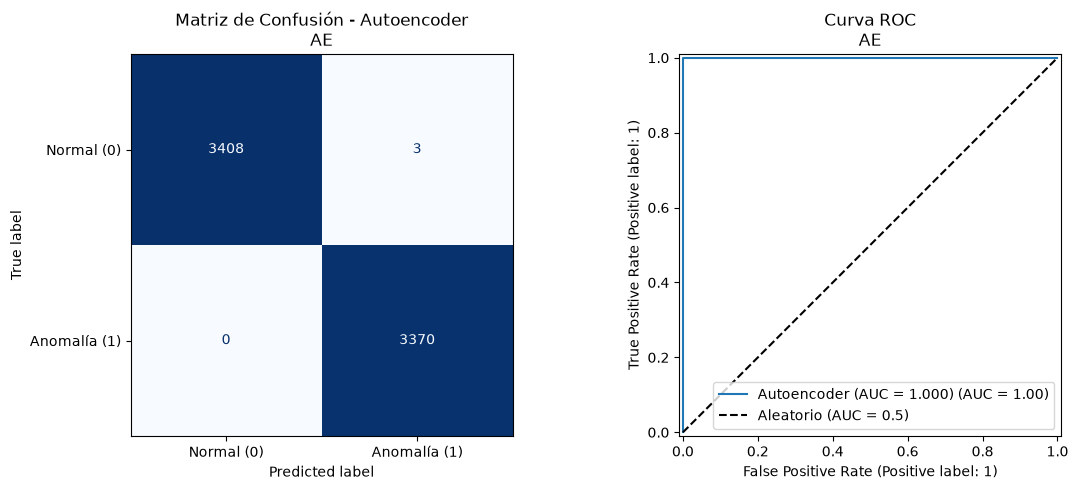

In [42]:


# Calcular los scores (Error de reconstrucción MSE por muestra) para X_test
print("\nCalculando errores de reconstrucción en el conjunto de test...")
reconstructions = autoencoder.predict(X_test)
scores = np.mean(np.power(X_test - reconstructions, 2), axis=1)

reconstructions_train = autoencoder.predict(X_correct_train)
train_scores = np.mean(np.power(X_correct_train - reconstructions_train, 2), axis=1)

# Predicción: Si el MSE supera el umbral es anomalía (1), si no, normal (0)
Y_pred = np.where(scores > threshold, 1, 0)

model_name = f'AE'

df_result[f'result_({model_name})'] = float('nan')
df_result[f'scores_({model_name})'] = float('nan')
df_result.loc[idx_test, f'result_({model_name})'] = Y_pred
df_result.loc[idx_test, f'scores_({model_name})'] = scores

# Mapeo de etiquetas reales (0 = normal/correct, 1 = anomalía)
y_true = df_result.loc[idx_test, 'label'].apply(lambda x: 0 if x == 'correct' else 1)
y_pred = df_result.loc[idx_test, f'result_({model_name})']

# Cálculo del AUC-ROC (en el Autoencoder, a mayor error de reconstrucción / score, mayor probabilidad de anomalía)
roc_auc = roc_auc_score(y_true, scores)

# 1. Componentes de la matriz de confusión
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

# 2. Cálculo de métricas
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = f1_score(y_true, y_pred, zero_division=0)

parametros = best_params.copy()
parametros['threshold_percentil_scores'] = threshold_percentil_scores

# 3. Guardar en el registro (añadiendo roc_auc)
reg_resultado_algoritmo = {
    'test_name': model_name,
    'parametros': json.dumps(parametros),
    'TP': int(tp),
    'FP': int(fp),
    'TN': int(tn),
    'FN': int(fn),
    'accuracy': float(acc),
    'precision': float(precision),
    'recall': float(recall),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc)
}

lista_result.append(reg_resultado_algoritmo)
df_anomaly_detection_summary = pd.DataFrame(lista_result)

# 4. Visualización conjunta (Matriz de Confusión a la izquierda, Curva ROC a la derecha)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica izquierda: Matriz de Confusión
disp_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Anomalía (1)'])
disp_cm.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Matriz de Confusión - Autoencoder\n{model_name}')

# Gráfica derecha: Curva ROC
RocCurveDisplay.from_predictions(
    y_true, 
    scores, 
    ax=axes[1], 
    name=f'Autoencoder (AUC = {roc_auc:.3f})'
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Aleatorio (AUC = 0.5)')
axes[1].set_title(f'Curva ROC\n{model_name}')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [43]:
paquete_autoencoder = {
    'model': autoencoder_final,                # El modelo de Keras ya entrenado
    'metrics_list': lista_metric_name_vector,  # La lista con los nombres de las características
    'model_name': "Autoencoder_TFM_Microservices", # Un identificador o nombre descriptivo
    'parametros': parametros           # Opcional: guardar los hiperparámetros ganadores
}
joblib.dump(paquete_autoencoder, f'{FOLDER_SALIDA}/models/{model_name}.joblib')

['result/models/AE.joblib']

In [44]:
df_anomaly_detection_summary

,test_name,parametros,TP,FP,TN,FN,accuracy,precision,recall,specificity,f1_score,roc_auc
0,AE,"{""latent_dim"": 32, ""hidden_units"": 96, ""learni...",3370,3,3408,0,0.999558,0.999111,1.0,0.99912,0.999555,NaN
1,AE,"{""latent_dim"": 32, ""hidden_units"": 96, ""learni...",3370,3,3408,0,0.999558,0.999111,1.0,0.99912,0.999555,1.0


In [45]:
df_anomaly_detection_summary.to_parquet(f'{FOLDER_SALIDA}/df_anomaly_detection_AE_summary.parquet', index=False,engine='fastparquet')